In [1]:
!gdown 1msLVo0g0LFmL9-qZ73vq9YEVZwbzOePF

Downloading...
From (original): https://drive.google.com/uc?id=1msLVo0g0LFmL9-qZ73vq9YEVZwbzOePF
From (redirected): https://drive.google.com/uc?id=1msLVo0g0LFmL9-qZ73vq9YEVZwbzOePF&confirm=t&uuid=9103d250-ca04-4d87-a63f-e3b66d8770c8
To: d:\Friday_Image_Retrieval-20240904T105050Z-001\Friday_Image_Retrieval\Solution\Code\data.zip

  0%|          | 0.00/76.1M [00:00<?, ?B/s]
  1%|          | 524k/76.1M [00:00<00:21, 3.46MB/s]
  4%|â–         | 3.15M/76.1M [00:00<00:05, 13.4MB/s]
  8%|â–Š         | 6.29M/76.1M [00:00<00:03, 19.7MB/s]
 12%|â–ˆâ–        | 8.91M/76.1M [00:00<00:03, 19.7MB/s]
 19%|â–ˆâ–‰        | 14.7M/76.1M [00:00<00:01, 31.1MB/s]
 25%|â–ˆâ–ˆâ–Œ       | 19.4M/76.1M [00:00<00:01, 31.9MB/s]
 30%|â–ˆâ–ˆâ–ˆ       | 23.1M/76.1M [00:00<00:01, 33.0MB/s]
 36%|â–ˆâ–ˆâ–ˆâ–Œ      | 27.3M/76.1M [00:00<00:01, 33.9MB/s]
 41%|â–ˆâ–ˆâ–ˆâ–ˆ      | 30.9M/76.1M [00:01<00:01, 32.6MB/s]
 45%|â–ˆâ–ˆâ–ˆâ–ˆâ–Œ     | 34.6M/76.1M [00:01<00:01, 31.7MB/s]
 50%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆ     | 38.3M/76.1M [00:01<

In [2]:
!unzip data

'unzip' is not recognized as an internal or external command,
operable program or batch file.


In [3]:
%pip install chromadb
%pip install open-clip-torch

   ---------------------------------------- 0.0/23.4 MB ? eta -:--:--
   ---- ----------------------------------- 2.9/23.4 MB 19.8 MB/s eta 0:00:02
   -------------- ------------------------- 8.4/23.4 MB 22.3 MB/s eta 0:00:01
   ----------------------- ---------------- 13.9/23.4 MB 24.3 MB/s eta 0:00:01
   --------------------------------- ------ 19.7/23.4 MB 25.0 MB/s eta 0:00:01
   ---------------------------------------  23.3/23.4 MB 24.3 MB/s eta 0:00:01
   ---------------------------------------- 23.4/23.4 MB 23.1 MB/s  0:00:01
   ---------------------------------------- 0.0/5.0 MB ? eta -:--:--
   --------------------------------- ------ 4.2/5.0 MB 20.0 MB/s eta 0:00:01
   ---------------------------------------- 5.0/5.0 MB 18.0 MB/s  0:00:00
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 2.0/2.0 MB 12.4 MB/s  0:00:00
   ---------------------------------------- 0.0/13.2 MB ? eta -:--:--
   --------- ---------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 13.9 MB/s  0:00:00
   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   ---------------------------------------- 2.6/2.6 MB 18.4 MB/s  0:00:00
   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   -- ------------------------------------- 5.8/114.6 MB 28.3 MB/s eta 0:00:04
   ---- ----------------------------------- 12.3/114.6 MB 29.5 MB/s eta 0:00:04
   ------- -------------------------------- 20.2/114.6 MB 32.5 MB/s eta 0:00:03
   ---------- ----------------------------- 28.8/114.6 MB 34.7 MB/s eta 0:00:03
   ------------ --------------------------- 36.7/114.6 MB 35.7 MB/s eta 0:00:03
   ---------------- ----------------------- 46.1/114.6 MB 37.5 MB/s eta 0:00:02
   ------------------- -------------------- 55.6/114.6 MB 38.4 MB/s eta 0:00:02
   ---------------------- ----------------- 63.2/114.6 MB 39.0 MB/s eta 0:00:02
   -


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import os
import chromadb
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from chromadb.utils.embedding_functions import OpenCLIPEmbeddingFunction

In [25]:
from pathlib import Path
from zipfile import ZipFile

def setup_data_root():
    cwd = Path.cwd()
    base_paths = [cwd, *cwd.parents]
    relative_paths = [Path('.'), Path('Friday_Image_Retrieval/Solution/Code'), Path('Solution/Code'), Path('Code')]

    for base_path in base_paths:
        for relative_path in relative_paths:
            data_path = base_path / relative_path / 'data'
            if (data_path / 'train').exists() and (data_path / 'test').exists():
                return data_path.as_posix()

    for base_path in base_paths:
        for relative_path in relative_paths:
            zip_path = base_path / relative_path / 'data.zip'
            if zip_path.exists():
                with ZipFile(zip_path, 'r') as zip_ref:
                    zip_ref.extractall(zip_path.parent)
                data_path = zip_path.parent / 'data'
                if (data_path / 'train').exists() and (data_path / 'test').exists():
                    return data_path.as_posix()

    raise FileNotFoundError("Cannot find data/train and data/test. Put data.zip in the notebook folder or run the download cell first.")

ROOT = setup_data_root()
CLASS_NAME = sorted(os.listdir(f'{ROOT}/train'))
HNSW_SPACE = "hnsw:space"


In [26]:
def get_files_path(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Data folder not found: {path}")

    files_path = []
    for label_path in sorted(path.iterdir()):
        if not label_path.is_dir():
            continue
        for file_path in sorted(label_path.iterdir()):
            if file_path.is_file():
                files_path.append(file_path.as_posix())
    return files_path

In [27]:
data_path = f'{ROOT}/train'
files_path = get_files_path(path=data_path)
files_path

['d:/Friday_Image_Retrieval-20240904T105050Z-001/Friday_Image_Retrieval/Solution/Code/data/train/African_crocodile/n01697457_10393.JPEG',
 'd:/Friday_Image_Retrieval-20240904T105050Z-001/Friday_Image_Retrieval/Solution/Code/data/train/African_crocodile/n01697457_104.JPEG',
 'd:/Friday_Image_Retrieval-20240904T105050Z-001/Friday_Image_Retrieval/Solution/Code/data/train/African_crocodile/n01697457_1331.JPEG',
 'd:/Friday_Image_Retrieval-20240904T105050Z-001/Friday_Image_Retrieval/Solution/Code/data/train/African_crocodile/n01697457_14906.JPEG',
 'd:/Friday_Image_Retrieval-20240904T105050Z-001/Friday_Image_Retrieval/Solution/Code/data/train/African_crocodile/n01697457_18587.JPEG',
 'd:/Friday_Image_Retrieval-20240904T105050Z-001/Friday_Image_Retrieval/Solution/Code/data/train/African_crocodile/n01697457_260.JPEG',
 'd:/Friday_Image_Retrieval-20240904T105050Z-001/Friday_Image_Retrieval/Solution/Code/data/train/African_crocodile/n01697457_5586.JPEG',
 'd:/Friday_Image_Retrieval-20240904T105

In [28]:
def plot_results(image_path, files_path, results):
    query_image = Image.open(image_path).resize((448,448))
    images = [query_image]
    class_name = []
    for id_img in results['ids'][0]:
        id_img = int(id_img.split('_')[-1])
        img_path = files_path[id_img]
        img = Image.open(img_path).resize((448,448))
        images.append(img)
        class_name.append(os.path.basename(os.path.dirname(img_path)))

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))

    # Iterate through images and plot them
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i])
        if i == 0:
            ax.set_title(f"Query Image: {os.path.basename(os.path.dirname(image_path))}")
        else:
            ax.set_title(f"Top {i+1}: {class_name[i-1]}")
        ax.axis('off')  # Hide axes
    # Display the plot
    plt.show()

In [29]:
embedding_function = OpenCLIPEmbeddingFunction()

def get_single_image_embedding(image):
    embedding = embedding_function._encode_image(image=np.array(image))
    return embedding

In [30]:
img_path = f'{ROOT}/train/African_crocodile/n01697457_260.JPEG'
img = Image.open(img_path)
get_single_image_embedding(image=img)

array([ 2.07571816e-02,  1.70052052e-02, -5.46765327e-02,  1.93033032e-02,
        3.82915547e-04,  1.24677755e-02, -1.62832793e-02, -2.15282035e-03,
        5.08179963e-02,  1.31859900e-02, -1.20895253e-02,  7.77475396e-03,
        1.88933294e-02, -3.94191332e-02,  1.14281503e-02,  2.29814872e-02,
       -6.46402612e-02,  2.64379531e-02,  1.48863494e-02,  2.71068630e-03,
       -4.40382697e-02, -6.41890801e-03,  5.66541683e-03, -3.08282096e-02,
       -1.64298955e-02, -3.53694428e-04,  5.32553252e-03, -1.52662396e-02,
       -7.75747001e-03, -2.55334172e-02, -1.27053224e-02,  1.91802140e-02,
        2.37119268e-03,  1.47357583e-02, -2.69960873e-02, -3.94066870e-02,
        1.54179931e-02, -1.43080754e-02, -3.24314833e-02,  1.03276558e-02,
       -1.65551864e-02,  4.11975011e-02, -3.55036482e-02, -1.55741116e-02,
        6.45225821e-03, -3.75169851e-02,  8.52111503e-02,  3.83746549e-02,
        1.91211682e-02,  6.38298364e-03, -9.49576125e-03, -1.40892137e-02,
        3.08665764e-02,  

In [31]:
def add_embedding(collection, files_path):
    if len(files_path) == 0:
        raise ValueError("files_path is empty. Run the ROOT/data setup cell and rebuild files_path from train data first.")

    ids = []
    embeddings = []
    for id_filepath, filepath in tqdm(enumerate(files_path)):
        ids.append(f'id_{id_filepath}')
        image = Image.open(filepath)
        embedding = get_single_image_embedding(image=image)
        embeddings.append(embedding)
    collection.add(
        embeddings=embeddings,
        ids=ids
    )

In [32]:
# Create a Chroma Client
chroma_client = chromadb.Client()
files_path = get_files_path(path=f'{ROOT}/train')

# Recreate the collection so this cell can be rerun without duplicate id errors
try:
    chroma_client.delete_collection(name="l2_collection")
except Exception:
    pass

# Create a collection
l2_collection = chroma_client.get_or_create_collection(name="l2_collection",
                                                       metadata={HNSW_SPACE: "l2"})
add_embedding(collection=l2_collection, files_path=files_path)

0it [00:00, ?it/s]

595it [00:45, 13.02it/s]


In [33]:
def search(image_path, collection, n_results):
    query_image = Image.open(image_path)
    query_embedding = get_single_image_embedding(query_image)
    results = collection.query(
        query_embeddings=[query_embedding],
        n_results=n_results # how many results to return
    )
    return results

In [34]:
test_path = f'{ROOT}/test'
test_files_path = get_files_path(path=test_path)
test_path = test_files_path[1]
l2_results = search(image_path=test_path, collection=l2_collection, n_results=5)

In [35]:
l2_results

{'ids': [['id_12', 'id_16', 'id_14', 'id_11', 'id_13']],
 'embeddings': None,
 'documents': [[None, None, None, None, None]],
 'uris': None,
 'included': ['metadatas', 'documents', 'distances'],
 'data': None,
 'metadatas': [[None, None, None, None, None]],
 'distances': [[0.5144281983375549,
   0.5364850759506226,
   0.5524583458900452,
   0.5835264921188354,
   0.7518174648284912]]}

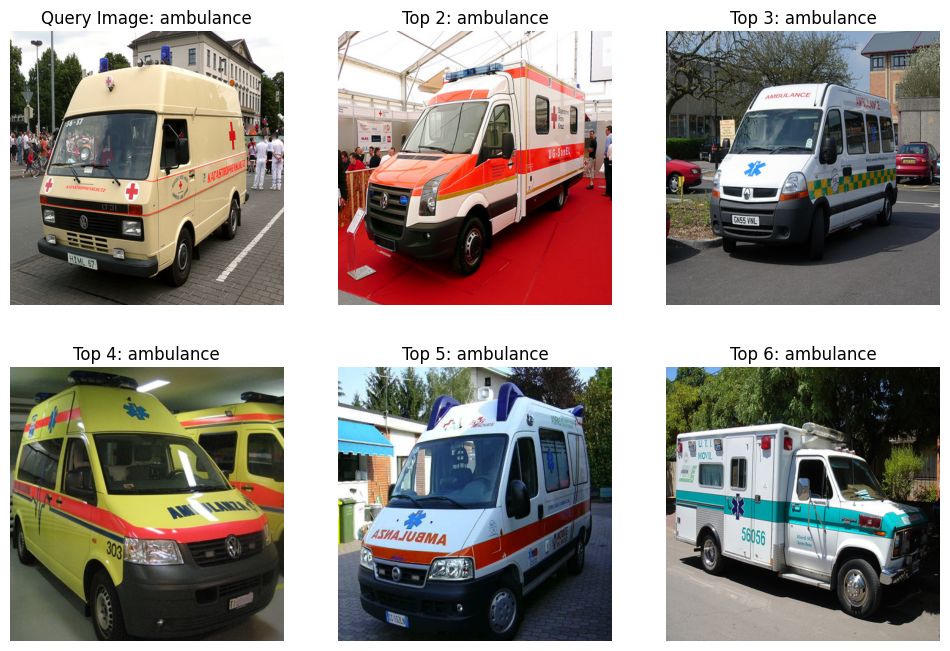

In [36]:
plot_results(image_path=test_path, files_path=files_path, results=l2_results)

In [37]:
# Create a Chroma Client
chroma_client = chromadb.Client()
files_path = get_files_path(path=f'{ROOT}/train')

# Recreate the collection so this cell can be rerun without duplicate id errors
try:
    chroma_client.delete_collection(name="Cosine_collection")
except Exception:
    pass

# Create a collection
cosine_collection = chroma_client.get_or_create_collection(name="Cosine_collection",
                                                           metadata={HNSW_SPACE: "cosine"})
add_embedding(collection=cosine_collection, files_path=files_path)

595it [00:44, 13.51it/s]


In [38]:
test_path = f'{ROOT}/test'
test_files_path = get_files_path(path=test_path)
test_path = test_files_path[1]
cosine_results = search(image_path=test_path, collection=cosine_collection, n_results=5)

In [39]:
cosine_results

{'ids': [['id_12', 'id_16', 'id_14', 'id_11', 'id_13']],
 'embeddings': None,
 'documents': [[None, None, None, None, None]],
 'uris': None,
 'included': ['metadatas', 'documents', 'distances'],
 'data': None,
 'metadatas': [[None, None, None, None, None]],
 'distances': [[0.2572143077850342,
   0.2682424783706665,
   0.27622896432876587,
   0.29176318645477295,
   0.3759084939956665]]}

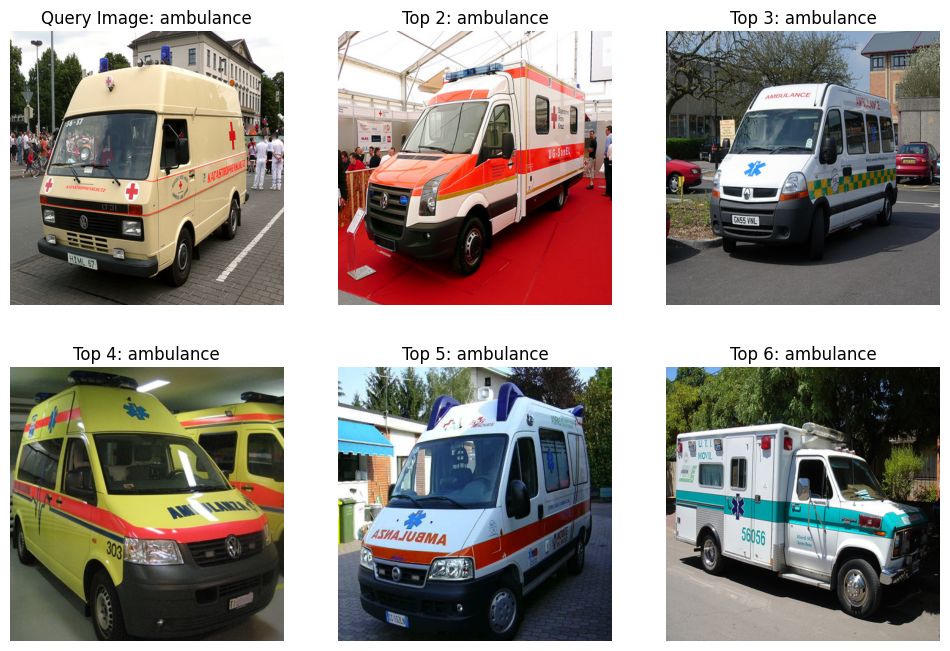

In [40]:
plot_results(image_path=test_path, files_path=files_path, results=cosine_results)